# CrisisInbox GRPO Training

Train a small LLM (Qwen2.5-0.5B) to triage crisis inbox messages using Group Relative Policy Optimization.

**What this does:**
1. Loads pre-generated episode data (inbox snapshots at decision points)
2. For each prompt, the model generates an action (which message to handle + response)
3. A reward function scores the action based on urgency, deadline, drift adaptation
4. GRPO updates the model to prefer higher-reward actions

Open in Google Colab with **T4 GPU** runtime.

In [40]:
# Install dependencies
!pip install unsloth trl transformers datasets accelerate peft -q
!pip install huggingface_hub -q

# Download episode data from the repo
!wget -q https://raw.githubusercontent.com/eptan/crisis-inbox/main/episodes.json
print("Setup complete")

Setup complete


In [41]:
# Avoid logging crash: transformers sometimes passes a Warning type to logger.warning(),
# which breaks %-style formatting. Patch so we don't pass that through.
import logging
import warnings

def _patch_transformers_logging():
    try:
        import transformers.utils.logging as trans_log
        _orig = trans_log.logger.warning
        def _safe_warning(msg, *args, **kwargs):
            # If first extra arg is a Warning type (e.g. FutureWarning), drop it for % formatting
            if args and isinstance(args[0], type) and issubclass(args[0], Warning):
                args = ()
            return _orig(msg, *args, **kwargs)
        trans_log.logger.warning = _safe_warning
    except Exception:
        pass
    warnings.filterwarnings("ignore", message=".*attention mask API.*", category=FutureWarning)

_patch_transformers_logging()

In [42]:
import torch

# Print GPU info (PyTorch uses total_memory, not total_mem)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total_bytes = getattr(props, "total_memory", None) or getattr(props, "total_mem", 0)
    vram_gb = total_bytes / 1e9 if total_bytes else 0
    if vram_gb == 0 and hasattr(torch.cuda, "mem_get_info"):
        _, total_bytes = torch.cuda.mem_get_info(0)
        vram_gb = total_bytes / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} ({vram_gb:.1f} GB)")
else:
    print("No GPU available.")

GPU: Tesla T4 (15.6 GB)


In [54]:
import json
import re
import random
from datasets import Dataset

# Load episodes
with open("episodes.json") as f:
    episodes = json.load(f)

# Flatten to individual training prompts
prompts = []
for ep in episodes:
    for dp in ep["decision_points"]:
        prompts.append({
            "prompt": dp["prompt"],
            "hour": dp["hour"],
            "visible_count": dp["visible_count"],
            "episode_id": ep["episode_id"],
            "seed": ep["seed"],
            "drift_events": ep["drift_events"],
            "superseded": ep.get("superseded_messages", {}),
            "messages": dp["visible_messages"],
        })

print(f"Loaded {len(episodes)} episodes -> {len(prompts)} training prompts")
print(f"Average {len(prompts)/len(episodes):.1f} decision points per episode")

Loaded 100 episodes -> 1600 training prompts
Average 16.0 decision points per episode


## Reward Function

Scores agent actions based on:
- **Urgency base** (critical=10, high=5, medium=3, low=1)
- **Deadline timing** (early=bonus, late=penalty)
- **Drift adaptation** (+50% for handling policy-change messages)
- **Stale info penalty** (-50% for acting on superseded messages)
- **Response quality** (penalty for short/empty responses)

In [55]:
def score_action(completion: str, prompt_data: dict) -> float:
    """
    Score a model completion against the inbox state.

    The model should output: respond_to_message(msg_id, "response text")
    We parse the message_id and response, then score based on the reward function.
    """
    messages = prompt_data["messages"]
    hour = prompt_data["hour"]
    superseded = prompt_data.get("superseded", {})

    # Parse the model output for message_id
    msg_id = None
    response_text = ""

    # Try to parse respond_to_message(msg_id, response)
    match = re.search(r'respond_to_message\s*\(\s*["\']?(msg_\d+)["\']?\s*,\s*["\'](.+?)["\']', completion, re.DOTALL)
    if match:
        msg_id = match.group(1)
        response_text = match.group(2)
    else:
        # Try simpler format: just a message ID mentioned
        id_match = re.search(r'(msg_\d+)', completion)
        if id_match:
            msg_id = id_match.group(1)
            response_text = completion

    if not msg_id:
        return -1.0  # couldn't parse any action

    # Find the message in the inbox
    target_msg = None
    for msg in messages:
        if msg["id"] == msg_id:
            target_msg = msg
            break

    if target_msg is None:
        return -0.5  # referenced a message not in inbox

    # Base reward by urgency
    urgency_rewards = {"critical": 10.0, "high": 5.0, "medium": 3.0, "low": 1.0}
    reward = urgency_rewards.get(target_msg["urgency"], 1.0)

    # Deadline timing
    deadline = target_msg.get("deadline_hours")
    if deadline is not None:
        if hour <= deadline:
            time_remaining_frac = (deadline - hour) / max(deadline, 1.0)
            reward *= 1.0 + 0.5 * time_remaining_frac
        else:
            reward *= 0.25  # late penalty

    # Response quality
    if len(response_text.strip()) < 10:
        reward *= 0.5

    # Drift adaptation bonus
    if target_msg.get("drift_flag"):
        reward *= 1.5

    # Stale info penalty
    if target_msg["id"] in superseded:
        reward *= 0.5

    # Bonus: penalize choosing low-urgency when critical exists
    has_critical = any(m["urgency"] == "critical" for m in messages)
    if has_critical and target_msg["urgency"] in ("low", "medium"):
        reward *= 0.3  # strong penalty for ignoring critical messages

    return round(reward, 2)


# Test the reward function
test_data = prompts[0]
print("Testing reward function on first decision point:")
print(f"  Hour: {test_data['hour']}, Messages: {test_data['visible_count']}")

# Simulate good action (pick critical message)
critical_msgs = [m for m in test_data["messages"] if m["urgency"] == "critical"]
if critical_msgs:
    good_action = f'respond_to_message("{critical_msgs[0]["id"]}", "Acknowledged. Evacuating immediately with documents and medication.")'
    good_score = score_action(good_action, test_data)
    print(f"  Good action (critical msg): {good_score:.2f} pts")

# Simulate bad action (pick low-urgency message)
low_msgs = [m for m in test_data["messages"] if m["urgency"] == "low"]
if low_msgs:
    bad_action = f'respond_to_message("{low_msgs[0]["id"]}", "ok")'
    bad_score = score_action(bad_action, test_data)
    print(f"  Bad action (low msg, short response): {bad_score:.2f} pts")

# Simulate unparseable action
junk_score = score_action("I think we should do something", test_data)
print(f"  Unparseable action: {junk_score:.2f} pts")

Testing reward function on first decision point:
  Hour: 0.0, Messages: 1
  Good action (critical msg): 7.50 pts
  Unparseable action: -1.00 pts


## Load Model & Configure GRPO

In [61]:
from unsloth import FastLanguageModel
import torch

# Load Qwen2.5-0.5B — small enough for T4 GPU
# Use a longer context window so prompt + completion
# comfortably fit without attention mask shape issues.
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-0.5B-Instruct",
    max_seq_length=4096,
    dtype=None,
    load_in_4bit=True,
)

# Add LoRA adapters for efficient fine-tuning
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

# GRPO requires left padding so completions align across the batch
tokenizer.padding_side = "left"
# GRPO expects left-padding so completion positions align across the batch
# (avoids completion_mask vs log-probs shape mismatch in masked_batch_mean).
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id



print("Model loaded with LoRA adapters")

==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded with LoRA adapters


In [57]:
# Build the training dataset
# Each row needs a "prompt" field formatted as chat messages.
# Use a conservative max length so every batch has identical shape (avoids mask mismatch).
MAX_PROMPT_LENGTH = 1024  # must match GRPOConfig max_prompt_length below

train_data = []
for p in prompts:
    msgs = [{"role": "user", "content": p["prompt"]}]
    tok = tokenizer.apply_chat_template(msgs, truncation=True, max_length=1024, return_tensors="pt", add_generation_prompt=True)
    # apply_chat_template can return a tensor or BatchEncoding. Do NOT use hasattr(tok, "shape")
    # (BatchEncoding.__getattr__ raises when attribute is missing). Use dict-like check instead.
    try:
        ids = tok["input_ids"]
    except (TypeError, KeyError):
        ids = tok
    n_tokens = ids.shape[1] if ids.dim() > 1 else ids.shape[0]
    if n_tokens > MAX_PROMPT_LENGTH:
        continue  # skip overlong prompts so batch shapes stay consistent
    train_data.append({
        "prompt": msgs,
        "_hour": p["hour"],
        "_episode_id": p["episode_id"],
    })

# Shuffle and split
random.seed(42)
random.shuffle(train_data)

dataset = Dataset.from_list(train_data)
print(f"Training dataset: {len(dataset)} prompts (after dropping prompts > {MAX_PROMPT_LENGTH} tokens)")
print(f"Sample prompt length: {len(train_data[0]['prompt'][0]['content'])} chars")

Training dataset: 1600 prompts (after dropping prompts > 1024 tokens)
Sample prompt length: 5113 chars


In [60]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

## GRPO Training Loop

The reward function scores each completion by:
1. Parsing which message the model chose to handle
2. Checking urgency, deadline timing, drift flags
3. Penalizing bad choices (low-urgency when critical exists, stale info)

In [62]:
from trl import GRPOConfig, GRPOTrainer

# Build a lookup from prompt text -> prompt metadata for reward scoring
prompt_lookup = {}
for p in prompts:
    key = p["prompt"][:200]  # use first 200 chars as key
    prompt_lookup[key] = p


def reward_fn(prompts, completions, **kwargs):
    """GRPO reward function. Scores each completion against its inbox state.
    Signature must match Unsloth GRPOTrainer: prompts, completions (keyword args)."""
    rewards = []
    for prompt_msgs, completion in zip(prompts, completions):
        # Extract the prompt text to look up metadata
        if isinstance(prompt_msgs, list):
            prompt_text = prompt_msgs[-1]["content"] if prompt_msgs else ""
        else:
            prompt_text = str(prompt_msgs)

        # Find the matching prompt data
        key = prompt_text[:200]
        prompt_data = prompt_lookup.get(key)

        if prompt_data is None:
            rewards.append(0.0)
            continue

        # Extract completion text (trainer may pass token ids or message dicts)
        if isinstance(completion, list):
            if completion and isinstance(completion[0], (int, float)):
                comp_text = tokenizer.decode(completion, skip_special_tokens=True)
            else:
                comp_text = completion[-1].get("content", "") if completion else ""
        else:
            comp_text = str(completion)

        score = score_action(comp_text, prompt_data)
        rewards.append(score)

    return rewards


# GRPO training config: conservative batch/length to avoid mask shape mismatch.
training_args = GRPOConfig(
    output_dir="crisisinbox-grpo-output",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
#    steps_per_generation=4,
    learning_rate=1e-5,
    max_completion_length=256,
    max_prompt_length=1024,
    num_generations=4,
    logging_steps=1,
    save_steps=100,
 #   report_to="none",
 #   bf16=False,
    fp16=True,
    # Adding sync_ref_model prevents some shape sync issues in Unsloth
    sync_ref_model=True,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=reward_fn,
    args=training_args,
    train_dataset=dataset,
)

print("Trainer configured — ready to train")

Trainer configured — ready to train


In [63]:
# Train!
trainer.train()
print("Training complete")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 1 | Total steps = 1,600
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / reward_fn / mean,rewards / reward_fn / std
1,0.444610,0.687500,1.125000,93.000000,15.000000,256.000000,0.250000,38.666668,15.000000,59.000000,0,0,0,0,0,0.000019,0.687500,1.125000
2,-0.643074,0.125000,1.299038,78.750000,7.000000,256.000000,0.250000,19.666668,7.000000,40.000000,No Log,No Log,No Log,No Log,No Log,0.000000,0.125000,1.299038
3,0.000000,-1.000000,0.000000,75.750000,39.000000,154.000000,0.000000,75.750000,39.000000,154.000000,No Log,No Log,No Log,No Log,No Log,0.000018,-1.000000,0.000000
4,-0.417545,0.187500,2.375000,133.000000,23.000000,256.000000,0.250000,92.000000,23.000000,228.000000,No Log,No Log,No Log,No Log,No Log,0.000026,0.187500,2.375000
5,0.351921,0.185000,0.837835,33.000000,16.000000,71.000000,0.000000,33.000000,16.000000,71.000000,No Log,No Log,No Log,No Log,No Log,0.000023,0.185000,0.837834
6,0.126111,1.100000,2.721519,66.250000,31.000000,88.000000,0.000000,66.250000,31.000000,88.000000,No Log,No Log,No Log,No Log,No Log,0.000025,1.100000,2.721519
7,0.092570,0.125000,1.299038,75.000000,9.000000,230.000000,0.000000,75.000000,9.000000,230.000000,No Log,No Log,No Log,No Log,No Log,0.000027,0.125000,1.299038
8,0.000000,0.125000,1.299038,29.500000,9.000000,72.000000,0.000000,29.500000,9.000000,72.000000,No Log,No Log,No Log,No Log,No Log,0.000011,0.125000,1.299038
9,-0.317522,0.042500,1.211291,35.250000,9.000000,66.000000,0.000000,35.250000,9.000000,66.000000,No Log,No Log,No Log,No Log,No Log,0.000046,0.042500,1.211291
10,-0.497801,0.250000,1.172604,69.750000,9.000000,116.000000,0.000000,69.750000,9.000000,116.000000,No Log,No Log,No Log,No Log,No Log,0.000021,0.250000,1.172604


Training complete


## Evaluate: Before vs After

Compare the trained model's action choices against the base model on the same prompts.

Evaluation, Saving, and Visualization

In [65]:
# Select 10 random prompts from your loaded 'prompts' list
eval_prompts = random.sample(prompts, min(10, len(prompts)))

=== Trained Model Evaluation ===

Hour   6.0 | Chose: msg_010  | Score: +5.0
Hour  24.5 | Chose: msg_016  | Score: +10.0
Hour  44.0 | Chose: msg_016  | Score: +10.0
Hour   6.0 | Chose: msg_010  | Score: +5.0
Hour  21.0 | Chose: msg_016  | Score: +10.0
Hour  18.0 | Chose: msg_016  | Score: +10.0
Hour  40.0 | Chose: msg_036  | Score: +15.7
Hour   6.0 | Chose: msg_002  | Score: +5.0
Hour  20.0 | Chose: msg_036  | Score: +19.4
Hour   6.0 | Chose: msg_010  | Score: +5.0

Average score: 9.52
Evaluation saved to grpo_eval_results.json


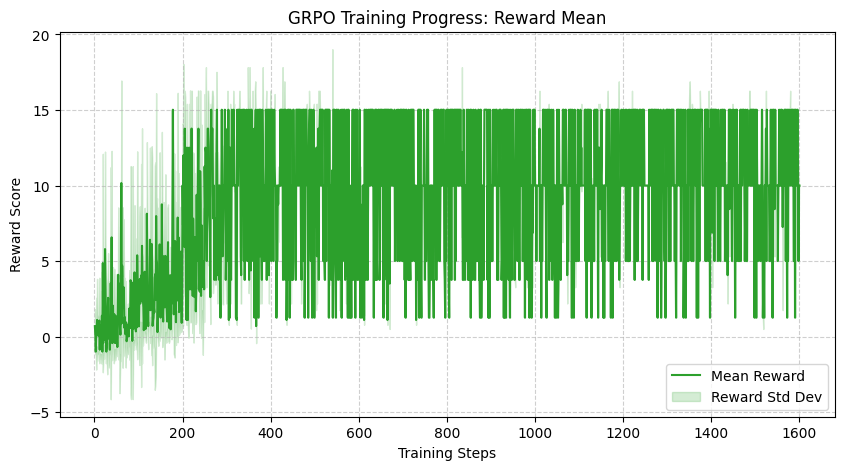

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import json

# 1. Run the Evaluation (using the clean version)
FastLanguageModel.for_inference(model)
eval_results = []
total_score = 0

print("=== Trained Model Evaluation ===\n")
for p in eval_prompts:
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": p["prompt"]}],
        return_tensors="pt", add_generation_prompt=True, return_dict=True
    ).to("cuda")

    prompt_len = inputs.input_ids.shape[1]
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=200, temperature=0.7, pad_token_id=tokenizer.pad_token_id)

    completion = tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True)
    score = score_action(completion, p)
    total_score += score

    # Parse for logging
    msg_match = re.search(r'(msg_\d+)', completion)
    chosen_id = msg_match.group(1) if msg_match else "none"

    res = {
        "hour": p["hour"],
        "chosen_id": chosen_id,
        "score": score,
        "completion": completion
    }
    eval_results.append(res)
    print(f"Hour {res['hour']:5.1f} | Chose: {res['chosen_id']:8s} | Score: {res['score']:+.1f}")

# 2. Save Results to JSON
with open("grpo_eval_results.json", "w") as f:
    json.dump(eval_results, f, indent=4)
print(f"\nAverage score: {total_score / len(eval_prompts):.2f}")
print("Evaluation saved to grpo_eval_results.json")

# 3. Plot Training Rewards
# trainer.state.log_history contains the metrics recorded during training
history = pd.DataFrame(trainer.state.log_history)

if 'rewards/reward_fn/mean' in history.columns:
    plt.figure(figsize=(10, 5))
    # Filter out rows that don't have the reward (like evaluation or save steps)
    reward_steps = history.dropna(subset=['rewards/reward_fn/mean'])

    plt.plot(reward_steps['step'], reward_steps['rewards/reward_fn/mean'], label='Mean Reward', color='#2ca02c')
    plt.fill_between(reward_steps['step'],
                     reward_steps['rewards/reward_fn/mean'] - reward_steps['rewards/reward_fn/std'],
                     reward_steps['rewards/reward_fn/mean'] + reward_steps['rewards/reward_fn/std'],
                     alpha=0.2, color='#2ca02c', label='Reward Std Dev')

    plt.title('GRPO Training Progress: Reward Mean')
    plt.xlabel('Training Steps')
    plt.ylabel('Reward Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("No reward history found. Ensure logging_steps was set > 0.")

In [67]:
# Evaluate on a few test prompts
FastLanguageModel.for_inference(model)

eval_prompts = random.sample(prompts, min(10, len(prompts)))
total_score = 0

print("=== Trained Model Evaluation ===\n")
for p in eval_prompts:
    messages = [{"role": "user", "content": p["prompt"]}]
    #raw = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True)
    # Do NOT use hasattr(raw, "shape") — BatchEncoding.__getattr__ raises. Use try/except.
    #try:
    #    inputs = {k: v.to("cuda") for k, v in raw.items()}
    #    prompt_len = inputs["input_ids"].shape[1]
    #except (TypeError, AttributeError):
    #    inputs = raw.to("cuda")
    #    prompt_len = inputs.shape[1]

    #with torch.no_grad():
    #    output = model.generate(inputs, max_new_tokens=200, temperature=0.7, do_sample=True)

   # Use return_dict=True to force a consistent format
    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True,
        return_dict=True
    ).to("cuda")

    # Now we know exactly where input_ids is
    prompt_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    completion = tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True)
    score = score_action(completion, p)
    total_score += score

    # Show a summary
    msg_match = re.search(r'(msg_\d+)', completion)
    chosen_id = msg_match.group(1) if msg_match else "none"
    chosen_msg = next((m for m in p["messages"] if m["id"] == chosen_id), None)
    urgency = chosen_msg["urgency"] if chosen_msg else "N/A"

    print(f"Hour {p['hour']:5.1f} | Chose: {chosen_id} ({urgency:8s}) | Score: {score:+.1f}")

print(f"\nAverage score: {total_score / len(eval_prompts):.2f}")

=== Trained Model Evaluation ===

Hour  28.0 | Chose: msg_036 (critical) | Score: +18.1
Hour  44.0 | Chose: msg_036 (critical) | Score: +15.9
Hour  25.5 | Chose: msg_016 (critical) | Score: +10.0
Hour  47.0 | Chose: msg_036 (critical) | Score: +3.8
Hour  44.0 | Chose: msg_036 (critical) | Score: +15.9
Hour   0.0 | Chose: msg_001 (critical) | Score: +7.5
Hour  18.0 | Chose: msg_016 (critical) | Score: +10.0
Hour  35.0 | Chose: msg_036 (critical) | Score: +16.6
Hour  23.5 | Chose: msg_016 (critical) | Score: +10.0
Hour  40.0 | Chose: msg_016 (critical) | Score: +10.0

Average score: 11.77


In [69]:
# Save the trained model
model.save_pretrained("crisisinbox-grpo-trained")
tokenizer.save_pretrained("crisisinbox-grpo-trained")
print("Model saved to crisisinbox-grpo-trained/")

Model saved to crisisinbox-grpo-trained/
